# Atelier Scikit-learn — Prédiction de l'état d'un capteur IoT

**Contexte.** Des capteurs mesurent température, humidité, pression et consommation. Chaque mesure a un **état** : `OK`, `ALERTE` ou `ERREUR`. On veut un modèle qui **prédit automatiquement l'état** d'une mesure à partir de ses valeurs numériques.

**Workflow ML classique suivi :**
Dataset → Chargement → Exploration → Nettoyage → X / y → Train/Test → Prétraitement → Modèle → `fit()` → `predict()` → Évaluation → Sauvegarde → Chargement → Réutilisation.

## Partie 0 — Mise en place de l'environnement

On importe **pandas** (manipulation de données), **matplotlib** et **seaborn** (visualisation). Le CSV se trouve dans `data/` ; le notebook s'exécutant depuis `notebooks/`, on remonte d'un niveau (`../data/...`).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/mesures_capteurs.csv")
print("Forme du dataframe :", df.shape)
df.head()

Forme du dataframe : (605, 9)


,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


### Exploration du dataframe

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [4]:
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


In [5]:
# Repartition de la variable cible 'etat'
df["etat"].value_counts(dropna=False)

etat
OK        567
ALERTE     29
ERREUR      5
NaN         4
Name: count, dtype: int64

**Observation importante.** Les classes sont **très déséquilibrées** : la grande majorité des mesures sont `OK`, `ALERTE` est rare et `ERREUR` très rare. Ce déséquilibre aura des conséquences sur l'évaluation (Partie 7).

## Partie 1 — Gestion des doublons

Un **doublon** est une ligne strictement identique à une autre. On le repère avec `duplicated()` puis on le supprime avec `drop_duplicates()`.

In [6]:
nb_doublons = df.duplicated().sum()
print("Nombre de doublons :", nb_doublons)

Nombre de doublons : 5


In [7]:
df = df.drop_duplicates()
print("Doublons apres suppression :", df.duplicated().sum())
print("Nouvelle forme :", df.shape)

Doublons apres suppression : 0
Nouvelle forme : (600, 9)


### Nettoyage nécessaire : lignes sans état

La cible `etat` contient quelques valeurs manquantes. Or **on ne peut ni entraîner ni évaluer** un modèle sur des lignes dont la réponse est inconnue. On supprime donc les lignes où `etat` est manquant (les valeurs manquantes **des caractéristiques**, elles, seront traitées proprement en Partie 4).

In [8]:
print("Etats manquants avant :", df["etat"].isna().sum())
df = df.dropna(subset=["etat"])
print("Etats manquants apres :", df["etat"].isna().sum())
print("Forme du dataframe :", df.shape)

Etats manquants avant : 4
Etats manquants apres : 0
Forme du dataframe : (596, 9)


## Partie 2 — Sélection de `y` (cible) et `X` (caractéristiques)

- **cible** `y` = `etat` (ce qu'on veut prédire),
- **caractéristiques** `X` = `temperature`, `humidite`, `pression`, `consommation` (les variables explicatives numériques).

In [9]:
caracteristiques = ["temperature", "humidite", "pression", "consommation"]
X = df[caracteristiques]
y = df["etat"]

print("X (5 premieres lignes) :")
print(X.head())
print("\ny (5 premieres valeurs) :")
print(y.head())

X (5 premieres lignes) :
   temperature  humidite  pression  consommation
0        25.46     58.06   1008.95        287.28
1        24.00     79.73    993.39        116.20
2        25.82     54.47   1010.32        288.50
3        28.23     69.39   1019.62        136.65
4        20.58     53.80   1016.58        182.62

y (5 premieres valeurs) :
0    OK
1    OK
2    OK
3    OK
4    OK
Name: etat, dtype: str


### Type de problème de Machine Learning

La cible `etat` prend des valeurs **catégorielles** (`OK`, `ALERTE`, `ERREUR`). Il s'agit donc d'un problème de **classification** — plus précisément de **classification multi-classe** (3 classes).

## Partie 3 — Découpage Train / Test

Conditions : 20 % pour le test, reproductibilité (`random_state`), et **`stratify=y`** pour conserver **les mêmes proportions de classes** dans le train et le test que dans les données d'origine — indispensable ici vu le déséquilibre des classes.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape, " | Test :", X_test.shape)
print("\nProportions train :\n", y_train.value_counts(normalize=True).round(3))
print("\nProportions test :\n", y_test.value_counts(normalize=True).round(3))

Train : (476, 4)  | Test : (120, 4)

Proportions train :
 etat
OK        0.943
ALERTE    0.048
ERREUR    0.008
Name: proportion, dtype: float64

Proportions test :
 etat
OK        0.942
ALERTE    0.050
ERREUR    0.008
Name: proportion, dtype: float64


## Partie 4 — Gestion des valeurs manquantes

`SimpleImputer` remplace chaque valeur manquante par une valeur calculée. On choisit la **médiane**.

In [11]:
print("Valeurs manquantes par colonne (X_train) :")
print(X_train.isna().sum())

Valeurs manquantes par colonne (X_train) :
temperature     5
humidite        4
pression        5
consommation    3
dtype: int64


**Pourquoi la médiane ?** La médiane est **robuste aux valeurs extrêmes (outliers)**. Contrairement à la moyenne, qui est tirée vers le haut ou le bas par quelques valeurs aberrantes, la médiane (valeur centrale) reste représentative. Sur des données de capteurs qui peuvent avoir des pics anormaux, c'est le choix prudent.

**Point méthodologique clé :** on calcule les médianes **uniquement sur `X_train`** (`fit`), puis on applique la transformation au train **et** au test (`transform`). Cela évite la *fuite de données* (data leakage) : le test doit rester "inconnu".

In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
imputer.fit(X_train)                       # apprend les medianes sur le train

print("Medianes apprises :", dict(zip(caracteristiques, imputer.statistics_.round(2))))

X_train_imputed = imputer.transform(X_train)
X_test_imputed  = imputer.transform(X_test)
print("\nValeurs manquantes restantes (train) :", np.isnan(X_train_imputed).sum())

Medianes apprises : {'temperature': np.float64(24.9), 'humidite': np.float64(65.38), 'pression': np.float64(1012.3), 'consommation': np.float64(206.59)}

Valeurs manquantes restantes (train) : 0


## Partie 5 — Mise à l'échelle (standardisation)

**Pourquoi standardiser ?** Le modèle KNN se base sur des **distances** entre points. Or nos variables ont des échelles très différentes (pression ~1000, température ~25). Sans mise à l'échelle, la pression **écraserait** les autres variables dans le calcul de distance. `StandardScaler` recentre chaque variable (moyenne 0) et la réduit (écart-type 1), pour que **toutes pèsent équitablement**.

Là encore : `fit` sur le **train** seulement, puis `transform` sur train et test.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_imputed)                # apprend moyennes et ecarts-types sur le train

print("Moyennes  :", scaler.mean_.round(2))
print("Ecarts-types :", scaler.scale_.round(2))

X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled  = scaler.transform(X_test_imputed)

Moyennes  : [  24.96   64.85 1012.08  210.15]
Ecarts-types : [ 4.19 10.16 10.99 73.42]


## Partie 6 — Entraînement et prédiction (KNN)

**KNN (k plus proches voisins)** classe une nouvelle mesure en regardant les **k=5** points d'entraînement les plus proches et en prenant la classe **majoritaire** parmi eux.

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)           # entrainement

y_pred = knn.predict(X_test_scaled)        # prediction sur le test
print("Quelques predictions :", y_pred[:15])

Quelques predictions : ['OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK'
 'OK']


### Comparaison prédictions / vraies valeurs

In [15]:
comparaison = pd.DataFrame({
    "vraie_valeur": y_test.values,
    "prediction": y_pred
})
comparaison["correct"] = comparaison["vraie_valeur"] == comparaison["prediction"]
print(comparaison.head(15))
print("\nBonnes predictions :", comparaison["correct"].sum(), "/", len(comparaison))

   vraie_valeur prediction  correct
0            OK         OK     True
1            OK         OK     True
2            OK         OK     True
3            OK         OK     True
4        ALERTE         OK    False
5            OK         OK     True
6            OK         OK     True
7            OK         OK     True
8            OK         OK     True
9            OK         OK     True
10           OK         OK     True
11           OK         OK     True
12           OK         OK     True
13           OK         OK     True
14           OK         OK     True

Bonnes predictions : 115 / 120


## Partie 7 — Évaluation du modèle

In [16]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.3f}")

Accuracy : 0.958


### Pourquoi l'accuracy ne suffit pas toujours ?

L'**accuracy** = proportion de prédictions correctes. Le piège : avec des classes **déséquilibrées**, un modèle qui prédit **toujours `OK`** obtiendrait déjà une accuracy très élevée (puisque presque tout est `OK`), **sans jamais détecter** une `ALERTE` ou une `ERREUR` — qui sont pourtant les cas les plus importants ! L'accuracy masque donc les mauvaises performances sur les classes rares.

### Matrice de confusion

Elle croise **vraies valeurs (lignes)** et **prédictions (colonnes)**. La diagonale = bonnes prédictions ; hors diagonale = erreurs.

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes = sorted(y.unique())               # ['ALERTE', 'ERREUR', 'OK']
cm = confusion_matrix(y_test, y_pred, labels=classes)
print("Classes :", classes)
print("Matrice de confusion :\n", cm)

Classes : ['ALERTE', 'ERREUR', 'OK']
Matrice de confusion :
 [[  2   0   4]
 [  1   0   0]
 [  0   0 113]]


### Visualisation de la matrice avec Seaborn

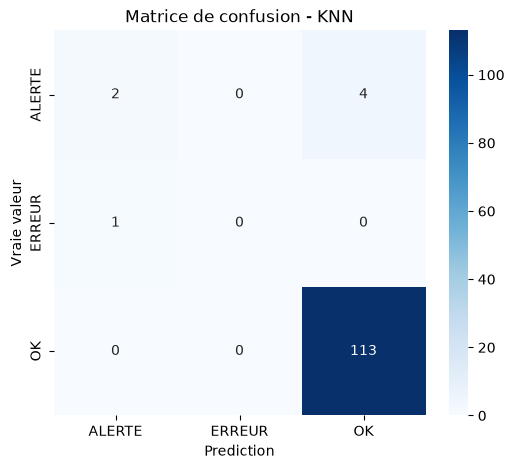

In [18]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Prediction")
plt.ylabel("Vraie valeur")
plt.title("Matrice de confusion - KNN")
plt.show()

**Commentaire.** Le modèle classe très bien les `OK` (classe majoritaire). En revanche il se trompe souvent sur `ALERTE` et surtout `ERREUR`, faute d'assez d'exemples pour ces classes à l'entraînement — conséquence directe du **déséquilibre**.

### Rapport de classification

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



**Commentaire.** Le rapport donne **precision**, **recall** et **f1-score** *par classe*. On voit que les scores sont bons pour `OK` mais faibles pour les classes rares : le modèle est bon "en moyenne" mais peu fiable pour détecter les anomalies.

### Quand privilégier chaque métrique ?

- **Precision** — quand le **coût d'une fausse alerte est élevé**. Elle répond à : "parmi ce que j'ai prédit `ALERTE`, combien l'étaient vraiment ?" (ex. éviter de déclencher une intervention coûteuse pour rien).
- **Recall (rappel)** — quand **rater un cas positif est grave**. "parmi les vraies `ERREUR`, combien ai-je détectées ?" (ex. détection de panne : mieux vaut une fausse alerte que rater une vraie erreur).
- **F1-score** — quand on veut un **compromis** entre precision et recall (moyenne harmonique). Utile justement en cas de **classes déséquilibrées**.
- **Accuracy** — appropriée quand les **classes sont équilibrées** et que toutes les erreurs ont la même importance.

## Partie 8 — Sauvegarde du modèle

Pour qu'un nouveau relevé "brut" puisse être prédit directement, on sauvegarde un **pipeline** qui enchaîne les trois étapes apprises : imputation (médiane) → standardisation → KNN. On le réentraîne sur `X_train` (données brutes) : il applique en interne exactement les mêmes transformations que ci-dessus.

In [20]:
from sklearn.pipeline import Pipeline
import joblib, pickle, os

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("knn",     KNeighborsClassifier(n_neighbors=5)),
])
pipeline.fit(X_train, y_train)             # X_train brut : le pipeline gere tout

os.makedirs("../models", exist_ok=True)

# Sauvegarde avec Joblib
joblib.dump(pipeline, "../models/modele_capteur.joblib")
# Sauvegarde avec Pickle
with open("../models/modele_capteur.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Modele sauvegarde (joblib + pkl) dans ../models/")

Modele sauvegarde (joblib + pkl) dans ../models/


## Partie 9 — Chargement du modèle et réutilisation

On recharge le modèle (via joblib) et on prédit l'état d'une **nouvelle mesure**. Comme c'est un pipeline, on lui passe directement les valeurs brutes.

In [22]:
modele_charge = joblib.load("../models/modele_capteur.joblib")

# Nouvelle mesure : temperature, humidite, pression, consommation
nouvelle_mesure = pd.DataFrame(
    [[26.5, 60.0, 1012.0, 250.0]],
    columns=caracteristiques
)

etat_predit = modele_charge.predict(nouvelle_mesure)
print("Etat predit pour la nouvelle mesure :", etat_predit[0])

Etat predit pour la nouvelle mesure : OK


## Partie 10 — Bonus : rééquilibrage des classes

Le point faible identifié est le **déséquilibre** (le modèle ignore les classes rares). Une amélioration utile : donner **plus de poids** aux voisins proches avec `weights="distance"`, ce qui aide un peu sur les classes rares. On compare l'accuracy et surtout le **f1-score macro** (moyenne non pondérée sur les classes → sensible aux classes rares).

In [23]:
from sklearn.metrics import f1_score

knn_ponderé = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn_ponderé.fit(X_train_scaled, y_train)
y_pred2 = knn_ponderé.predict(X_test_scaled)

print("KNN uniforme  - accuracy :", round(accuracy_score(y_test, y_pred), 3),
      "| f1_macro :", round(f1_score(y_test, y_pred, average='macro', zero_division=0), 3))
print("KNN pondere   - accuracy :", round(accuracy_score(y_test, y_pred2), 3),
      "| f1_macro :", round(f1_score(y_test, y_pred2, average='macro', zero_division=0), 3))

KNN uniforme  - accuracy : 0.958 | f1_macro : 0.476
KNN pondere   - accuracy : 0.967 | f1_macro : 0.529


**Conclusion.** Le `f1_macro` est bien plus révélateur que l'accuracy quand les classes sont déséquilibrées. Pour aller plus loin en production, on collecterait davantage d'exemples `ALERTE`/`ERREUR` ou on utiliserait des techniques de rééquilibrage (sur-échantillonnage type SMOTE, ou `class_weight`).